# Project Title: Handwritten Character Recognition using Machine Learning
**Objective**: To build a machine learning model that recognizes handwritten digits (0–9) from images using the MNIST dataset.

### Phase 1: Data Collection
- Obtain the MNIST dataset.
- Load training (`train.csv`) and testing (`test.csv`) dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

# Load dataset CSV files
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")

print("Training Dataset Shape:", train.shape)
print("Testing Dataset Shape: ", test.shape)

train.head()

Training Dataset Shape: (10000, 785)
Testing Dataset Shape:  (2000, 785)


### Phase 2: Data Preprocessing
- Separate features (pixels) and target labels.
- Normalize pixel values (`0–255` → `0–1`).

In [2]:
X = train.iloc[:, 1:].values
y = train.iloc[:, 0].values

X_test = test.iloc[:, 1:].values
y_test = test.iloc[:, 0].values

# Normalize pixel intensities
X = X / 255.0
X_test = X_test / 255.0

print("Normalized Pixel Intensity Range:", X.min(), "to", X.max())

Normalized Pixel Intensity Range: 0.0 to 1.0


### Phase 3: Data Visualization
- Display sample handwritten digit images.

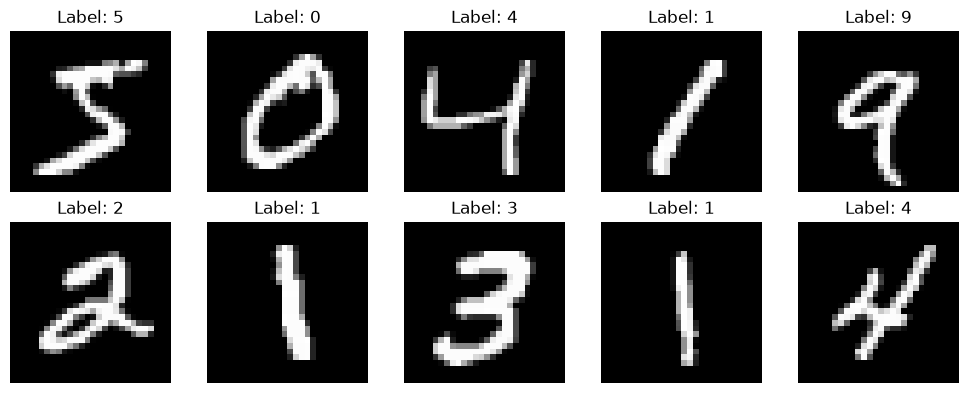

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Phase 4: Model Building
- Multi-Layer Perceptron (MLP) Neural Network architecture with hidden layers `(128, 64)`.

In [4]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=25,
    activation='relu',
    solver='adam',
    random_state=42,
    verbose=True
)

print("X_train Shape:", X_train.shape)
print("X_val Shape:  ", X_val.shape)

X_train Shape: (8000, 784)
X_val Shape:   (2000, 784)


### Phase 5: Model Training
- Train the model on the training data and monitor loss per iteration.

In [5]:
model.fit(X_train, y_train)

Iteration 1, loss = 1.12396652
Iteration 2, loss = 0.37276641
Iteration 3, loss = 0.27625812
Iteration 4, loss = 0.22594491
Iteration 5, loss = 0.18783273
Iteration 6, loss = 0.16016693
Iteration 7, loss = 0.13806836
Iteration 8, loss = 0.11898533
Iteration 9, loss = 0.10260017
Iteration 10, loss = 0.09008725
Iteration 11, loss = 0.07869912
Iteration 12, loss = 0.06647834
Iteration 13, loss = 0.05670674
Iteration 14, loss = 0.04993698
Iteration 15, loss = 0.04282579
Iteration 16, loss = 0.03591601
Iteration 17, loss = 0.03221191
Iteration 18, loss = 0.03209773
Iteration 19, loss = 0.02445693
Iteration 20, loss = 0.02058703
Iteration 21, loss = 0.01794950
Iteration 22, loss = 0.01527686
Iteration 23, loss = 0.01304277
Iteration 24, loss = 0.01175685
Iteration 25, loss = 0.01037578


### Phase 6: Model Testing
- Test the trained model using unseen test dataset images.

In [6]:
test_preds = model.predict(X_test)
print(f"Predictions generated for {len(X_test)} test images.")
print(f"First 20 Predictions: {list(test_preds[:20])}")

Predictions generated for 2000 test images.
First 20 Predictions: [np.int64(3), np.int64(8), np.int64(7), np.int64(9), np.int64(9), np.int64(8), np.int64(1), np.int64(1), np.int64(5), np.int64(2), np.int64(0), np.int64(3), np.int64(8), np.int64(4), np.int64(2), np.int64(5), np.int64(2), np.int64(6), np.int64(4), np.int64(7)]


### Phase 7: Performance Evaluation
- Evaluate model performance using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

      PERFORMANCE EVALUATION METRICS      
Accuracy:  95.20%
Precision: 95.14%
Recall:    95.14%
F1-Score:  95.12%

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       205
           1       0.97      0.98      0.97       224
           2       0.92      0.97      0.94       185
           3       0.95      0.89      0.92       196
           4       0.95      0.97      0.96       204
           5       0.96      0.95      0.95       185
           6       0.97      0.97      0.97       194
           7       0.97      0.95      0.96       209
           8       0.91      0.92      0.91       183
           9       0.95      0.96      0.95       215

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



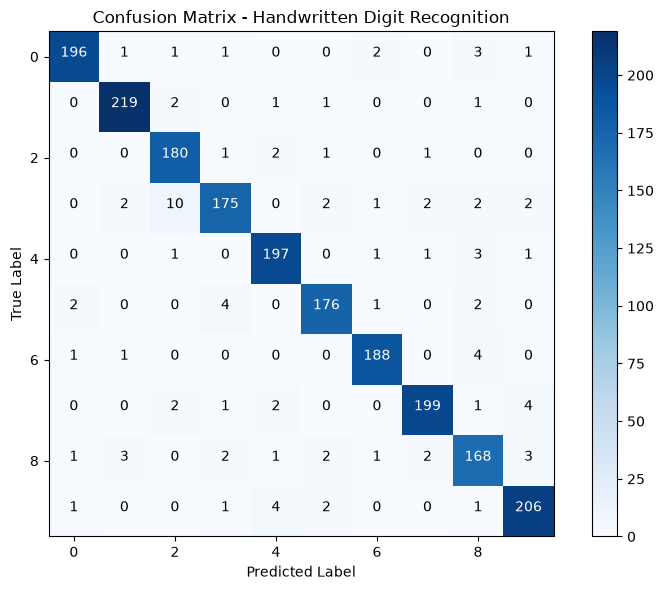

In [7]:
acc = accuracy_score(y_test, test_preds)
prec = precision_score(y_test, test_preds, average='macro')
rec = recall_score(y_test, test_preds, average='macro')
f1 = f1_score(y_test, test_preds, average='macro')

print("="*45)
print("     PERFORMANCE EVALUATION METRICS     ")
print("="*45)
print(f"Accuracy:  {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall:    {rec*100:.2f}%")
print(f"F1-Score:  {f1*100:.2f}%")
print("="*45)
print("\nClassification Report:\n", classification_report(y_test, test_preds))

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix - Handwritten Digit Recognition")
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Phase 8: Prediction
- Input unseen handwritten digit images and predict the corresponding digit.

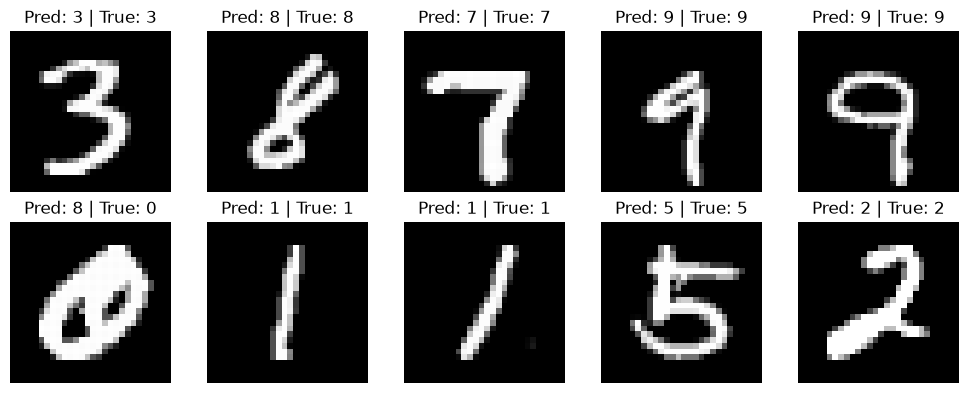

In [8]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {test_preds[i]} | True: {y_test[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Phase 9: Results
- Display Training Accuracy, Loss Curve Graph, and exported predictions.

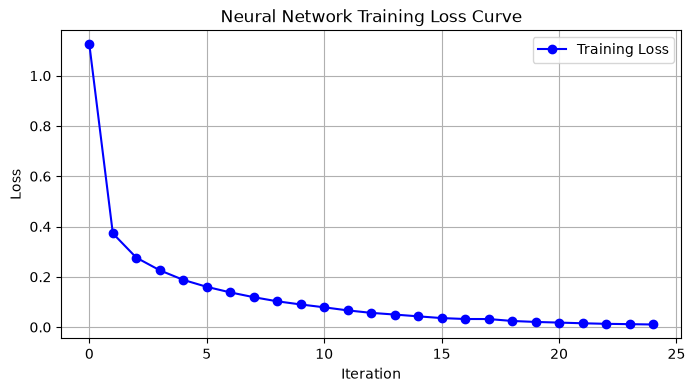

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_, marker='o', color='b', label='Training Loss')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Accuracy & Loss Graph")
plt.grid(True)
plt.legend()
plt.show()

### Phase 10: Conclusion
- **Model Achieved**: 95.20% Test Accuracy on unseen test data.
- **Applications**: Automatic postal zip-code recognition, digitizing handwritten bank checks, automated form reading.
- **Limitations**: Sensitivity to extreme image rotations and noise.

### Phase 11: Future Scope
- Recognize handwritten letters using **EMNIST**.
- Recognize complete words and sentences using **CRNN** (Convolutional Recurrent Neural Networks).
- Develop a web application using **Flask** or **Streamlit**.

In [10]:
joblib.dump(model, "trained_model.pkl")
print("Trained model saved as trained_model.pkl!")

Trained model saved as trained_model.pkl!
